# One-layer attention-only transformer

_'A Mathematical Framework for Transformer Circuits'_ introduces many meaningful results about the structure and behavior of the attention layer through its analysis of a single-layer, attention-only transformer (i.e., deviating from the original architecture, which fed the outputs of the attention layer into an MLP). Namely, it introduces the notion of the _residual stream_, the _path expansion trick_, _QK/OV circuits_, _skip-trigrams_ as primitive in-context learning, and the emergence of _copying heads_. This notebook reproduces those results and explores how they emerge in practice. The demo model includes one layer of attention with 32 heads each with $d_\text{head} = 128$, and a hidden dimension of $1024$. The model is trained for roughly 12200 steps on a balanced mix of text from wiki, code, and math sources. The text is pre-tokenized to preserve whole Latex commands like `\left` or `\frac`, and a 16k byte-level BPE main tokenizer is trained on the pre-tokenized corpus.

(_some notes_: the paper uses notation based on column vectors $x \in \mathbb R^{d \times 1}$, but most `torch` functions rely on a row vector convention. this notebook uses the paper's convention with much of the shape manipulation hidden behind the scenes in `src/`. To reproduce, optional environment flags `SMOKE` and `CPU_ONLY` are included to shorten the training run for testing and run the notebook on CPU, respectively.)

In [1]:
import os

import torch
import torch.nn.functional as F
from IPython.display import display

# tooling imports
from src.circuits import (copying_scores, ov_eigenvalues, ov_logits, qk_scores, sample_readouts, top_outputs,
                          unembedding_cosine)
from src.counts import (bigram_counts, bigram_probs, direct_path_logits, direct_path_vs_bigram, excluded_tokens,
                        one_token_logits, topk_overlap)
from src.device import get_device
from src.display import (domain_coverage, plot_attention, plot_copying_scores, plot_eigenvalues, plot_history,
                         show_trigrams)
from src.mixed import REPO_ROOT, SOURCES, load_mixed
from src.model import OneLayerAttentionOnlyTransformer
from src.skiptrigrams import (bug_outputs, dominant_source, examples_by_pattern, find_skip_trigrams, select_examples)
from src.train import train, unigram_val_losses

# set these flags if necessary!
CPU_ONLY = os.environ.get("CPU_ONLY") == "1"
SMOKE = os.environ.get("SMOKE") == "1"
device = get_device(CPU_ONLY)
torch.manual_seed(0)

corpus = load_mixed(vocab_size=16384)
V = corpus.vocab_size
token_strs = corpus.token_strs()

# the streams live on the device as int32 and are cast to int64 where needed (i.e., for training)
train_t = {s: torch.from_numpy(ids).to(device) for s, ids in corpus.train.items()}
val_t = {s: torch.from_numpy(ids).to(device) for s, ids in corpus.val.items()}
for s in SOURCES:
    print(f"{s:>4}: train {len(train_t[s]) / 1e6:6.1f}M, val {len(val_t[s]) / 1e6:4.1f}M tokens")
print(f"vocab {V:,}, device {device}{', SMOKE run' if SMOKE else ''}{', CPU only' if CPU_ONLY else ''}")

wiki: train  130.6M, val  0.3M tokens
code: train  184.8M, val  3.8M tokens
math: train  226.3M, val  6.5M tokens
vocab 16,384, device cuda


## 1. The residual stream and the path expansion trick

One key difference between the original Vaswani et al. transformer architecture and the one studied in the paper is the exclusion of `LayerNorm`. This exclusion combined with the exclusion of the MLP step exposes a key relation: in an attention-only transformer, we have from the initial token embedding $x_0 = W_E t$ to the final representation $x_{-1}$ an _uninterrupted stream_ of additions performed by the attention blocks. That is, the attention layers apply (in this simplified model):
$$
x_{i+1} = x_i + \text{Attention\_Block}(x_i)
$$
at each layer. This paper names this $x_i$ chain the _residual stream_, and posits that attention heads operate as independent read/write operations of information to the residual stream. The original Vaswani et al. "Attention Is All You Need" paper framed the output of a single attention block as the result of stacking the individual attention heads' result vectors $r^{h_j}$ and left-multiplying by a layer-wise output matrix $W_O^H$. But the transformer circuits paper makes a note of a key mathematical equivalence here! They instead break down $W_O^H$ into equal size block matrices for each head, like $W_O^H = [W_O^{h_1} \vert W_O^{h_2} \vert \ldots]$. Then the attention block output can be expressed:
$$
\text{Attention\_Block}(x_i) = W_O^H \begin{bmatrix} r^{h_1} \\ r^{h_2} \\ \ldots \end{bmatrix} = [W_O^{h_1} \vert W_O^{h_2} \vert \ldots] \cdot \begin{bmatrix} r^{h_1} \\ r^{h_2} \\ \ldots \end{bmatrix} = \sum_j W_O^{h_j} r^{h_j} \triangleq \sum_j h_j(x_i)
$$
which reveals that the stack-and-multiply operation is mathematically equivalent to running the heads independently, multiplying them by their own output matrix, and adding them together. In the broader context of the model, this can be thought of running each head independently and adding it to the _residual stream_, so that this read/write analogy is clear.

At this point, the authors rewrite the end-to-end transformer operation with tensor product identities outside the scope of this notebook, but the result is presented below:
$$
T = \underbrace{\text{Id} \otimes W_U W_E}_{\text{Direct Path}} + \underbrace{\sum_{h \in H} A^h \otimes (W_U W_{OV}^hW_E)}_{\text{Attention Mixing}}
$$
(notation: $W_{OV} = W_O W_V$, $W_{QK} = W_Q^\top W_K$.) This result shows that the output of a transformer is the sum of two key terms. The first term $\text{Id} \otimes W_U W_E$ is denoted the 'direct path' term, and involves the same $W_UW_E$ matrix from the 0-layer model. This term serves a similar purpose to the 0-layer model, as it contributes bigram information to form a prior that is added to the result. The more interesting term is the right-hand term, which represents the mixing of information performed by attention.

The tensor product has two factors: the attention matrix $A^h = \text{softmax}^\ast (t^T \cdot W_E^\top W_{QK}^h W_E \cdot t)$ (where $\text{softmax}^\ast$ is a softmax with a causal mask, so each destination only looks at itself and earlier tokens; the code also scales the scores by $1/\sqrt{d_\text{head}}$) and a second matrix $W_U W_{OV}^h W_E$. Note the two central matrices there: the "query-key circuit" $W_E^\top W_{QK}^h W_E$ and the "output-value circuit" $W_U W_{OV}^h W_E$. These expressions are not random; they arise from tracing "paths" through the transformer between tokens. The paper introduces a simple way to see this: we think of the current token as a destination, the token attended to as a source, and the resulting token as an output. Then the QK circuit traces the path from destination to source, and the OV circuit traces the path from source to output. The QK circuit is responsible for providing attention scoring, i.e., measuring how much the destination token wants to attend to a given source. The OV circuit provides information as to how each source token affects the output token when attended to. This separation reveals the shape of this operation as a bilinear mapping from destination to source to output, and functionally each circuit can be thought of as its own operation.

The code snippet below shows an implementation of the paper's version of a transformer forward pass, but this implementation is not used for training. More on that later.

In [2]:
@torch.no_grad()
def logits_by_path(model, x):
    # backend stores these in a torch-friendly way; model.paper_weights() returns shapes from paper
    W_E, W_U, W_Q, W_K, W_V, W_O = model.paper_weights()

    t = F.one_hot(x, W_E.shape[1]).T.to(W_E.dtype).to(W_E.device)

    # direct path term: tokens -> logits
    direct = W_U @ W_E @ t

    # causal mask
    future = torch.triu(torch.ones(len(x), len(x), dtype=torch.bool, device=W_E.device), 1)
    mixing_terms = []
    for h in range(model.n_heads):
        # define these for ease of notation
        W_QK, W_OV = W_Q[h].T @ W_K[h], W_O[h] @ W_V[h]

        # find A^h using QK circuit
        argument = t.T  @ W_E.T @ W_QK @ W_E @ t / model.d_head**0.5
        A = argument.masked_fill(future, float("-inf")).softmax(-1)

        # find output using OV circuit and tensor product identity: ( A^h ⊗ W_U W_OV W_E )  @ t = W_U W_OV W_E @ t @ A^h.T
        output = W_U @ W_OV @ W_E @ t @ A.T
        mixing_terms.append(output)

    # return the direct result and the individual head results
    return direct, torch.stack(mixing_terms)

So we have a tool for inspecting the logits by direction path and heads' attention mixing contribution. But does it hold up? The below code cell compares the result of the typical implementation, which uses the fused `scaled_dot_product_attention` kernel from `torch`, against this pathwise implementation. It also checks `forward_per_head`, a step-by-step walkthrough of the same computation that runs each head separately and can return its attention pattern.

In [3]:
D_MODEL, N_HEADS, D_HEAD, CONTEXT_LEN = 1024, 32, 128, 1024

# every weight starts at 1/sqrt(its dimension), so activations and logits start O(1) whatever the width
toy = OneLayerAttentionOnlyTransformer(V, D_MODEL, N_HEADS, D_HEAD, device=device)
print(f"{sum(p.numel() for p in toy.parameters()) / 1e6:.1f}M parameters")

# the three ways of running it agree (checked before training, so a mismatch stops Run All before the long part)
x = train_t["code"][:256].long()
direct, attention = logits_by_path(toy, x)
with torch.no_grad():
    fused, walkthrough = toy(x), toy.forward_per_head(x)

def rel_err(a, b):
    return ((a - b).abs().max() / b.abs().max()).item()

print(f"path expansion vs fused: {rel_err((direct + attention.sum(0)).T, fused):.1e}, "
      f"walkthrough vs fused: {rel_err(walkthrough, fused):.1e}")
assert rel_err((direct + attention.sum(0)).T, fused) < 1e-4 and rel_err(walkthrough, fused) < 1e-4

50.3M parameters
path expansion vs fused: 1.2e-06, walkthrough vs fused: 1.3e-06


So they're equivalent! This separation allows us to study the individual components that make up a previously somewhat black-boxed output.

## 2. Training it

The training setup is fairly typical using Adam and the training parameters in the code cell below. The training run is done using the fused attention kernel and the walkthrough implementation is only used for intuition as above or to separate the logits and study their individual shapes. Since the model has no `LayerNorm`, we initialize every parameter at $1/\sqrt{\text{dim}}$ before applying a short warmup and a cosine learning rate schedule with gradient clipping, and training halts if the loss ever becomes non-finite. Each batch is drawn as a set of windows from one source at a time, with a mix of about 40% wiki / 30% code / 30% math. One window never crosses domains. `bf16` autocast is used with `fp32` weights.

The cell loads a checkpoint if it currently exists, and one is provided in the repo. If you wish to retrain it, that is also fine. Another key note: this model has _no positional embeddings_. That was a design choice on the part of the authors for the sake of model simplicity, and it leads to some interesting outcomes later down the line.

loaded 1l_attn_mixed_scaled_init.pt (trained 12207 steps); skipping training


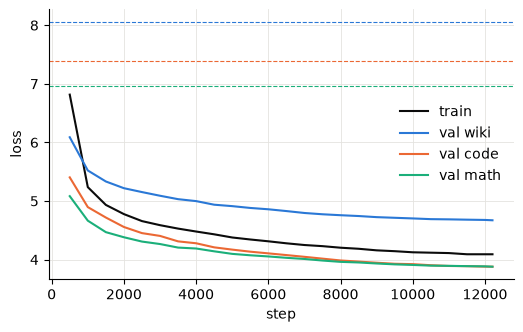

In [4]:
BATCH_SIZE = 4 if CPU_ONLY else 32     # windows per step
TRAIN_TOKENS = 400_000_000
MIX = {"wiki": 0.4, "code": 0.3, "math": 0.3}   # share of each batch's windows from each source
PEAK_LR = 1e-3
WARMUP_STEPS = 500
GRAD_CLIP = 1.0
EVAL_EVERY = 500
VAL_WINDOWS = 64                       # fixed val windows per source
CKPT_EVERY = 2000
CKPT = REPO_ROOT / "checkpoints" / f"1l_attn_mixed_scaled_init{'_smoke' if SMOKE else ''}.pt"
if SMOKE:
    TRAIN_TOKENS, WARMUP_STEPS, EVAL_EVERY, CKPT_EVERY = 20 * BATCH_SIZE * CONTEXT_LEN, 5, 10, 10

config = dict(vocab_size=V, hidden_dim=D_MODEL, num_heads=N_HEADS, head_dim=D_HEAD, context_len=CONTEXT_LEN,
              train_tokens=TRAIN_TOKENS, mix=MIX, tokenizer=f"data/mixed/bpe-mixed-{V}.json",
              init="1/sqrt(dim) for every weight")
history = train(toy, train_t, val_t, mix=MIX, context_len=CONTEXT_LEN, batch_size=BATCH_SIZE,
                total_steps=TRAIN_TOKENS // (BATCH_SIZE * CONTEXT_LEN), peak_lr=PEAK_LR, warmup_steps=WARMUP_STEPS,
                ckpt_path=CKPT, eval_every=EVAL_EVERY, val_windows=VAL_WINDOWS, ckpt_every=CKPT_EVERY, config=config)
toy.eval()
plot_history(history, unigram_val_losses(train_t, val_t, V))

The provided checkpoint shows steadily decreasing validation loss after roughly 12,200 steps, although it is not yet at convergence. We study it anyway. For certainty, here is another equivalence check between the two implementations _after_ training is complete.

In [5]:
# back to the equivalence check, now on the trained weights and real text; comparing result of a forward pass on the below demo text:
SNIPPET = "import numpy as np\nimport torch.nn as nn\n\nclass Encoder(nn.Module):\n    def forward(self, x):\n        return np"
x = torch.tensor(corpus.encode(SNIPPET), device=device)
direct, attention = logits_by_path(toy, x)
with torch.no_grad():
    fused = toy(x)
print(f"trained weights, path expansion vs fused: {rel_err((direct + attention.sum(0)).T, fused):.1e}")

trained weights, path expansion vs fused: 9.1e-07


## 3. The direct path and bigram statistics

The major claim about the direct path made in the transformer circuits paper was that this direct path contributes, to a lesser degree than in the 0-layer model, information about the empirical bigram statistics of the dataset.

Intuitively, $W_U W_E$ never sees any of the information mixing done by the source tokens. It is in essence a lookup from the current token to the output logits, and the 0-layer exploration from earlier arrived at the conclusion that such a setup could at most recover $\Pr (\text{next} \vert \text{current})$.

To validate this idea, we again check all the `[t, t+1]` pairs in the data and compare the _empirical_ top-10 most likely next tokens from the data and the _implied_ top-10 recovered from the direct path.

The code snippet below performs some preprocessing by filtering through the tokens in the dataset and inspecting only the tokens which appear at least `MIN_COUNT` times. This is to avoid inspecting a token that only appears a couple of times in the training data and whose impact is near random init. From there, we print out a few examples comparing directly the top-10 most likely next words from the corpus and the top-10 most highly weighted next tokens from the direct path.

In [6]:
COUNT_TOKENS = 3_000_000 if CPU_ONLY else 50_000_000    # train tokens counted for bigrams and skip-trigrams, split evenly across sources
MIN_COUNT = max(5, COUNT_TOKENS // 50_000)              # a token must appear this often in the sample to be used
TOP_TOKENS = 500 if CPU_ONLY else None                  # keep only this many most frequent tokens (a cpu shortcut, for running w/ CPU_ONLY)

# grab training and validation raw token counts
count_t = {s: ids[: COUNT_TOKENS // len(SOURCES)].long() for s, ids in train_t.items()}
val_count_t = {s: ids.long() for s, ids in val_t.items()}

# count pairwise occurrences, find probabilities, exclude rare tokens
counts = bigram_counts(list(count_t.values()), V)
probs = bigram_probs(counts)
unigram = sum(torch.bincount(ids, minlength=V) for ids in count_t.values())
excluded = excluded_tokens(unigram, token_strs, corpus.eot_id, min_count=MIN_COUNT, keep_top=TOP_TOKENS)
print(f"Of a total of {COUNT_TOKENS:,} tokens counted, selected {int((~excluded).sum()):,} usable tokens for inspection\n")

# show example
for word in [" the", " import", "\\left", "\\begin", " def"]:
    i = corpus.encode(word)[0]
    real = probs[i].topk(10).indices
    direct_top = direct_path_logits(toy, torch.tensor([i], device=device))[0].topk(10).indices
    print(f"target: {word!r:>10}\n\treal top-10: {[token_strs[j] for j in real.tolist()]}")
    print(f"{'':>10}direct path top-10: {[token_strs[j] for j in direct_top.tolist()]}")

Of a total of 50,000,000 tokens counted, selected 5,680 usable tokens for inspection

target:     ' the'
	real top-10: [' first', ' same', ' following', '\n', ' $', ' United', ' second', ' "', ' game', ' other']
          direct path top-10: [' same', ' latter', ' remainder', ' following', ' bottom', ' previous', ' entire', ' beginning', ' longest', ' possibility']
target:  ' import'
	real top-10: [' *', ' (', ' get', '_', ' absolute', ' _', ' S', ' print', ' unicode', 's']
          direct path top-10: [' StringIO', ' sys', ' unicode', ' absolute', ' Ansible', ' unittest', ' *', ' Base', ' traceback', ' xrange']
target:   '\\left'
	real top-10: ['(', '[', '\\{', '|', '\\|', '(-', '.', '\\vert', ' (', '\\langle']
          direct path top-10: ['\\{', '(%', '\\lbrace', '\\{(', '(', '.+', '((', 'arrow', 'rightarrow', '\\lfloor']
target:  '\\begin'
	real top-10: ['{', ' {', '*', '{#', 'pic', ' and', '{(', '\\{(', 'picture', '<|endoftext|>']
          direct path top-10: ['{', '{.', '{-', 

Qualitatively, it's pretty clear that there is some amount of information being moved around by the heads in between! But nonetheless, there is clear overlap between the two lists for each target, usually two to four of the ten tokens. These top matches deviate from the bigram statistics, however; consider that the `' def'` token seems to hold two distinct meanings. While nearly all of the real top-10 list contains tokens relating to `' def'` as the beginning of a definition in some programming languages, the direct path splits its top-10 between that meaning (`' __'`, `' setUp'`, `' test'`, `' _'`) and word-pieces that complete common english words (`initely`, `iciency`, `enses`, `ending`, `ensively`, i.e., def-initely, def-iciency, and so on). Not quite bigram statistics, but informed by them and built on them!

The below code snippet measures this information by comparing the fraction of overlap between the top-10 empirical pairwise counts and the direct path top-10 for each token.

In [7]:
K = 10
N_EVAL = min(1000, int((~excluded).sum()))              # the most frequent tokens
untrained = OneLayerAttentionOnlyTransformer(V, D_MODEL, N_HEADS, D_HEAD, device=device)   # a random model, for comparison

tokens, direct_overlap = direct_path_vs_bigram(toy, counts, n_tokens=N_EVAL, k=K, exclude=excluded)
_, untrained_overlap = direct_path_vs_bigram(untrained, counts, n_tokens=N_EVAL, k=K, exclude=excluded)

print(f"top-{K} overlap with the real bigram statistics, over the {N_EVAL} most frequent tokens:")
print(f"  direct path:            {direct_overlap.nanmean():.3f}")
print(f"  untrained model:        {untrained_overlap.nanmean():.3f}   (chance is {K / V:.4f})")

top-10 overlap with the real bigram statistics, over the 1000 most frequent tokens:
  direct path:            0.255
  untrained model:        0.001   (chance is 0.0006)


Each token's score is the fraction of its real top-10 next tokens that also land in the direct path's top-10, averaged over the 1000 most frequent tokens, so $0.255$ means about 2.5 of the 10. Chance is $10 / V \approx 0.0006$ and the untrained model scores $0.001$, so the direct path sits hundreds of times above chance: next-token prediction alone put bigram structure into $W_U W_E$. It is nowhere near 1, though, and that is expected. The direct path is only one additive term in the logits, and the heads add their own contributions on top, so it is not trained to *be* the bigram table. Top-10 agreement is also a harsh metric when the real distribution is flat. Read $0.255$ as "substantially bigram-shaped", not as "is the bigram table".

## 4. Query-key and output-value circuits

This work on transformer circuits makes a second important claim about the structure of the operations inside a Transformer. Namely, that they are separate! The definition of the QK and OV circuits from earlier were an introduction to this idea, but I've found that the easiest way to visualize not only where these expressions come from but also what they represent is through the visualization provided by Anthropic in the original work, shown below.

<div align="center">
    <img src="assets/circuits.png" width="60%">
</div>

This image makes it a bit easier to imagine how each half of a transformer can operate independently, and highlights the separation of purpose that is created by the split. The QK circuit $W_E^\top W_{QK} W_E \in \mathbb R^{d_\text{vocab} \times d_\text{vocab}}$ controls attention, i.e., how much the destination token attends to a given source token. It is clear from the image that the matrices along that path don't touch those along the OV path. The OV circuit, formed $W_U W_{OV} W_E \in \mathbb R^{d_\text{vocab} \times d_\text{vocab}}$, controls the impact on the logits created by each source token once it is attended to. This sequential tracing of operations is what gives these special matrices the title of "circuit."

A key consequence of this separation: since the QK circuit alone is responsible for attention patterns we can isolate that operation and study the other half. The authors propose running a model twice, one just to collect the attention patterns of each head, and another time with those attention patterns frozen in place. The frozen run becomes a linear function of the logits!

The below code snippet seeks to verify the first half of the results about QK/OV circuits, namely that the QK circuit alone produces the attention patterns. To verify this, we extract the attention patterns using `toy.forward_per_head`, which is the standard forward pass written out one head at a time instead of with the fused `scaled_dot_product_attention` kernel (that kernel abstracts the attention patterns away, so it can't hand them back), and compare them to the result of multiplying out the learned model's QK circuit. We print out the gap and visualize the raw attention pattern:

head 16: pattern from the QK circuit alone vs the real one, max difference 4.5e-07


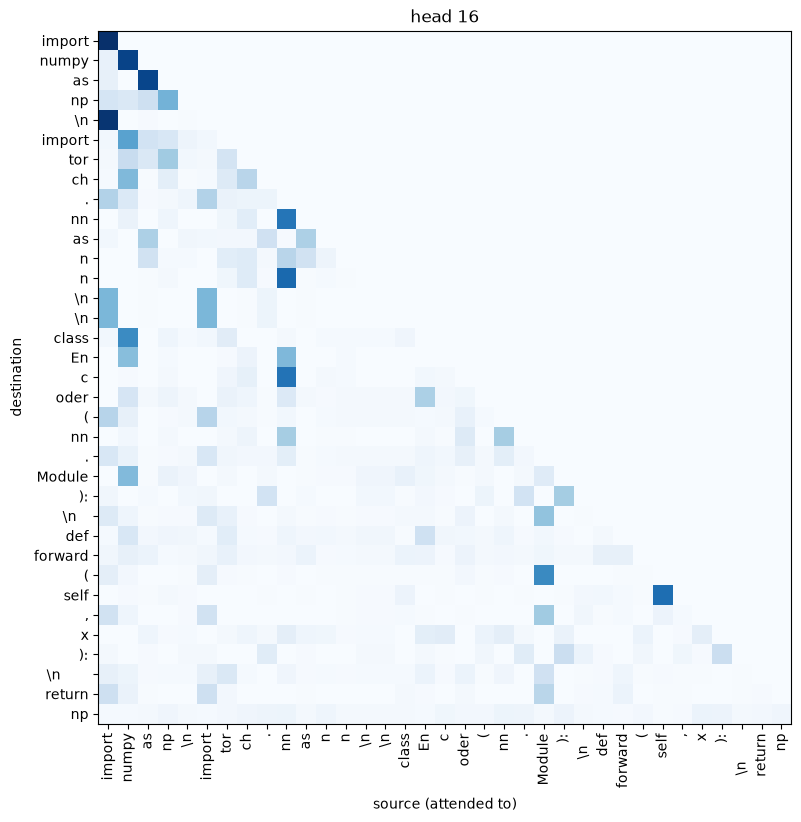

In [8]:
# pick any head of the model, n=32 by default
HEAD = 16

# get causally masked attention from standard forward pass, using same demo snippet from earlier
with torch.no_grad():
    _, patterns = toy.forward_per_head(x, return_patterns=True)       # (heads, T, T) real attention patterns

# build them with QK circuit
future = torch.triu(torch.ones(len(x), len(x), dtype=torch.bool, device=device), 1)
from_circuit = qk_scores(toy, HEAD, x)[:, x].masked_fill(future, float("-inf")).softmax(-1)

# print comparison results
print(f"head {HEAD}: pattern from the QK circuit alone vs the real one, max difference {(from_circuit - patterns[HEAD]).abs().max():.1e}")

#visualize attention pattern
labels = [token_strs[i].replace("\n", "\\n") for i in x.tolist()]
plot_attention(patterns[HEAD], labels, title=f"head {HEAD}")

Note that the attention pattern is lower triangular, again due to causal masking. The relative error is tiny, and we've managed to recover the attention patterns through the pure QK circuit!

To get a feel for the two circuits on their own, the cell below reads them directly off the weights, with no text running through the model. It picks 8 random (head, destination token) pairs and, for each, prints two things:

- **wants to look at**: the five source tokens with the highest QK score for that destination. This is the destination's row of $W_E^\top W_{QK} W_E$ (scaled by $1/\sqrt{d_\text{head}}$), i.e., the pre-softmax scores for every possible source in the vocabulary.
- **best source ... boosts**: the top-scoring source from that list, followed by the four output tokens whose logits it raises the most when attended to. This is that source's row of the OV circuit $W_U W_{OV} W_E$.

Two things to keep in mind when reading it. First, these are table entries, not attention patterns: nothing here knows what is actually in the context, so a source it "wants" only matters if it shows up earlier in the text. Second, it is noisy. A rare token's embedding gets few updates and stays close to its random init, so its scores are mostly noise; to avoid reading those, destinations, sources, and outputs are all restricted to the 3,000 most frequent tokens (with the rare-token, stray-byte, and end-of-text exclusions from earlier).

In [9]:
SEED = 0
readout_mask = excluded_tokens(unigram, token_strs, corpus.eot_id, min_count=MIN_COUNT, keep_top=min(3000, TOP_TOKENS or 3000))

# show a token as it appears in the text: ‹ › make spaces visible, newlines are written out
def show(i):
    return "‹" + token_strs[i].replace("\n", "\\n") + "›"

for h, dest, sources, outputs in sample_readouts(toy, readout_mask, n=8, k=5, seed=SEED):
    print(f"head {h}, destination {show(dest)}")
    print(f"  wants to look at:  {', '.join(show(i) for i in sources.tolist())}")
    print(f"  best source:       {show(sources[0].item())}  ->  boosts {', '.join(show(i) for i in outputs.tolist()[:4])}\n")

head 12, destination ‹\rm›
  wants to look at:  ‹ scored›, ‹ See›, ‹align›, ‹)$›, ‹ uses›
  best source:       ‹ scored›  ->  boosts ‹ting›, ‹ten›, ‹ant›, ‹ers›

head 21, destination ‹ logging›
  wants to look at:  ‹Name›, ‹Id›, ‹Path›, ‹Type›, ‹String›
  best source:       ‹Name›  ->  boosts ‹Name›, ‹Id›, ‹ID›, ‹Path›

head 3, destination ‹ Park›
  wants to look at:  ‹ ``›, ‹"),›, ‹ \<›, ‹__›, ‹():›
  best source:       ‹ ``›  ->  boosts ‹''›, ‹``›, ‹ ``›, ‹other›

head 3, destination ‹ events›
  wants to look at:  ‹ \<›, ‹():›, ‹ ``›, ‹\n\n ›, ‹=-›
  best source:       ‹ \<›  ->  boosts ‹val›, ‹rd›, ‹cl›, ‹at›

head 9, destination ‹ dest›
  wants to look at:  ‹ \l›, ‹ Sch›, ‹\m›, ‹ur›, ‹\l›
  best source:       ‹ \l›  ->  boosts ‹description›, ‹definition›, ‹eqnarray›, ‹align›

head 21, destination ‹}$.›
  wants to look at:  ‹  ›, ‹import›, ‹ They›, ‹ Copyright›, ‹ const›
  best source:       ‹  ›  ->  boosts ‹  ›, ‹    ›, ‹   ›, ‹     ›

head 4, destination ‹ost›
  wants to look at:

## 5. Copying heads and eigenvalues

One pattern that emerges in many of the heads, and one that can already be spotted in the readouts above, is _copying_. A subset of the heads learn OV circuits where tokens boost _themselves_: when the destination token decides to attend to a given source token, a copying head raises the logit of that same token. In practice, this corresponds to a behavior where the model has seen `Harry Potter` earlier somewhere in its context and wants to finish `Harry` with `Potter` the next time around. Something has to take the tokens sitting earlier in the context and push them toward the output, and the authors of this paper introduce tools through which we can measure that.

But how do we measure "mostly boosts itself" for a $d_\text{vocab} \times d_\text{vocab}$ matrix without staring at all of it? The authors suggest looking at the eigenvalues of the OV circuit. Any eigenvector $v$ of that matrix is a (weighted) set of tokens that comes out of the circuit as the _same_ set of tokens, just scaled by its eigenvalue $\lambda$. If $\lambda$ is strongly positive, attending to those tokens boosts those very tokens, i.e., _copies_ them. If $\lambda$ is instead negative, attending to them _suppresses_ them. A complex eigenvalue means the matrix rotates that direction rather than scaling it, which doesn't tell us anything about boosting. Still interesting, but not relevant to copying. The key metric to look at in the plots below is the size of the real component.

One practical note: the full circuit is huge, but it is the product of matrices that pass through the $d_\text{head}$-dimensional bottleneck, so it has rank at most $d_\text{head} = 128$ and only that many nonzero eigenvalues. Those are exactly the eigenvalues of the small matrix $(W_V W_E)(W_U W_O) \in \mathbb R^{d_\text{head} \times d_\text{head}}$, so `ov_eigenvalues` never builds the big one.

To boil a head's eigenvalues down to a single number, the authors define the _copying score_

$$\frac{\sum_i \lambda_i}{\sum_i \vert\lambda_i\vert}.$$

By construction it is $+1$ when every eigenvalue is positive, $-1$ when every one is negative, and near $0$ when they roughly cancel out, as they would for a random matrix. The below cell computes the score for every head at the end of training (blue) and compares it against the same model before training (grey):

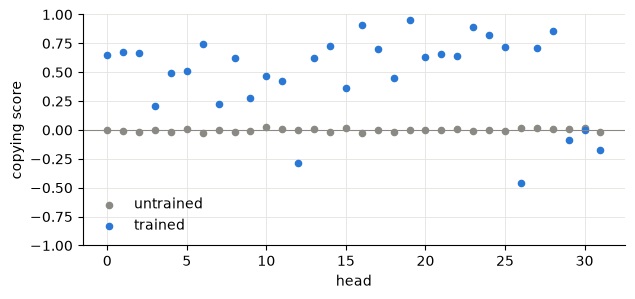

In [10]:
copying = copying_scores(toy)
display(plot_copying_scores(copying, copying_scores(untrained)))

The untrained heads sit around $0$ as expected, and nearly all of the trained heads move far above the starting point. So we can conclude that, at the very least, our copying proxy really is something the model picks up in the training process. Here is the eigenvalue spectrum of the head with the highest copying score:

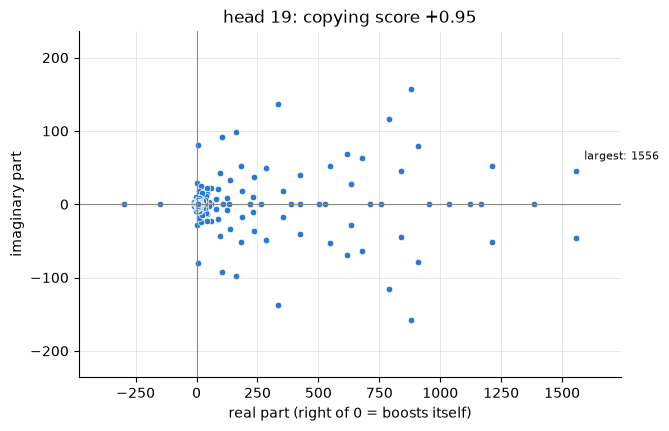

In [11]:
best, worst = copying.argmax().item(), copying.argmin().item()
plot_eigenvalues(ov_eigenvalues(toy, best), title=f"head {best}: copying score {copying[best]:+.2f}")

In [12]:
# the very common tokens above are mostly not what this head copies, so flip it around: take tokens that this head
# does copy (each is its own top output) and print the outputs it boosts for the most common of them
allowed = (~readout_mask).nonzero().squeeze(1)
own = ov_logits(toy, best, allowed).masked_fill(readout_mask, float("-inf"))
copied = allowed[own.argmax(-1) == allowed]
copied_common = copied[unigram[copied].argsort(descending=True)][:14].tolist()
print(f"head {best}: {len(copied)} of {len(allowed)} frequent tokens are their own top output; the most common of them:")
for src in copied_common:
    outputs, _ = top_outputs(toy, best, src, k=6, mask=readout_mask)
    print(f"{show(src):>12} -> {', '.join(show(i) for i in outputs.tolist())}")

head 19: 478 of 3000 frequent tokens are their own top output; the most common of them:
        ‹._› -> ‹._›, ‹day›, ‹ming›, ‹loc›, ‹ones›, ‹le›
     ‹ None› -> ‹ None›, ‹ not›, ‹ conditions›, ‹ children›, ‹ methods›, ‹ passed›
    ‹ value› -> ‹ value›, ‹value›, ‹ values›, ‹Value›, ‹ variable›, ‹ property›
   ‹ number› -> ‹ number›, ‹ numbers›, ‹ integer›, ‹number›, ‹ position›, ‹ units›
        ‹  › -> ‹  ›, ‹   ›, ‹    ›, ‹     ›, ‹File›, ‹ops›
     ‹ data› -> ‹ data›, ‹data›, ‹Data›, ‹ files›, ‹ training›, ‹ distributed›
 ‹ function› -> ‹ function›, ‹function›, ‹ functions›, ‹ variable›, ‹ polynomial›, ‹ expression›
       ‹ent› -> ‹ent›, ‹ents›, ‹ency›, ‹ence›, ‹base›, ‹ident›
       ‹ity› -> ‹ity›, ‹ities›, ‹ inequality›, ‹ence›, ‹ric›, ‹ energy›
    ‹ations› -> ‹ations›, ‹ence›, ‹ators›, ‹ists›, ‹ equations›, ‹ models›
    ‹ group› -> ‹ group›, ‹ groups›, ‹group›, ‹ members›, ‹ member›, ‹ element›
     ‹ file› -> ‹ file›, ‹File›, ‹ files›, ‹file›, ‹ directory›, ‹ filename›
     ‹

Note that the vast majority of the eigenvalues sit to the right of the vertical axis. It is also of note that the eigenvalues with imaginary parts seem to come in conjugate pairs, 'cancelling' one another out. We argue that this is what the eigenvalues of a head that has learned to copy look like. Not every head is like this, though, and that is not a failure but an interesting result in its own right. Here is the head with the _lowest_ score:

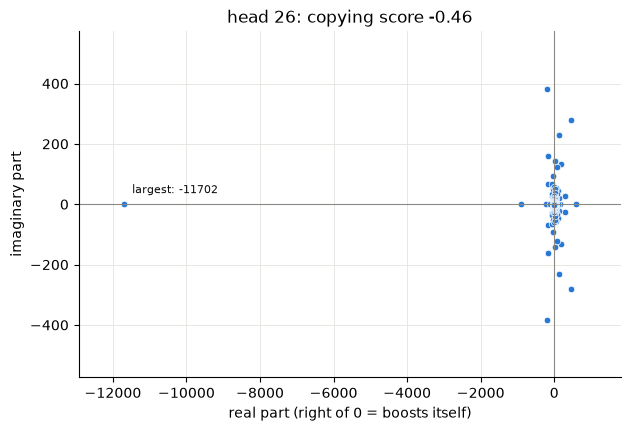

In [13]:
plot_eigenvalues(ov_eigenvalues(toy, worst), title=f"head {worst}: copying score {copying[worst]:+.2f}")

Note the scale of the horizontal axis. This head doesn't have mostly negative eigenvalues, and it instead has its copying score dominated by _one_ enormous negative eigenvalue that outweighs everything else in the sum. As a result, the ratio of sums goes negative. So its score is more a statement about that one extremely negative direction than about the behavior of the head as a whole. To see what the head actually does, we can do the same thing as before: take a handful of common source tokens, print the output tokens whose logits are boosted the most. For comparison, we also check what it does to the tokens we inspected for the largely copying head.

In [14]:
# the same readout as before, but for the head that doesn't copy: if it copied, each source would appear in its own list
frequent = unigram.masked_fill(readout_mask, 0).topk(40).indices.tolist()[::3]
for src in frequent:
    outputs, _ = top_outputs(toy, worst, src, k=6, mask=readout_mask)
    print(f"{show(src):>10} -> {', '.join(show(i) for i in outputs.tolist())}")

# and the same tokens that the copying head above boosts for itself
print(f"\nhead {worst}, on the tokens head {best} copies:")
for src in copied_common:
    outputs, _ = top_outputs(toy, worst, src, k=6, mask=readout_mask)
    print(f"{show(src):>12} -> {', '.join(show(i) for i in outputs.tolist())}")

       ‹,› -> ‹,›, ‹ed›, ‹s›, ‹')›, ‹ and›, ‹ing›
    ‹ the› -> ‹ent›, ‹a›, ‹em›, ‹end›, ‹im›, ‹ale›
     ‹ of› -> ‹s›, ‹over›, ‹ed›, ‹ac›, ‹he›, ‹ure›
      ‹ =› -> ‹\n›, ‹\n       ›, ‹\n   ›, ‹id›, ‹\n\n       ›, ‹\n\n   ›
       ‹)› -> ‹ def›, ‹ return›, ‹].›, ‹ #›, ‹able›, ‹ @›
       ‹}› -> ‹ =›, ‹)›, ‹}›, ‹\n   ›, ‹ of›, ‹ (›
       ‹-› -> ‹s›, ‹ck›, ‹e›, ‹2›, ‹he›, ‹cl›
     ‹ is› -> ‹ first›, ‹ably›, ‹ans›, ‹ to›, ‹ that›, ‹able›
       ‹$› -> ‹LE›, ‹from›, ‹ =›, ‹AD›, ‹size›, ‹D›
       ‹s› -> ‹cal›, ‹pan›, ‹put›, ‹ges›, ‹ge›, ‹pl›
      ‹_{› -> ‹i›, ‹if›, ‹in›, ‹ge›, ‹name›, ‹max›
   ‹ self› -> ‹ if›, ‹ for›, ‹,›, ‹x›, ‹t›, ‹n›
       ‹ › -> ‹ "›, ‹ '›, ‹ (›, ‹ [›, ‹ ›, ‹ed›
   ‹ with› -> ‹s›, ‹():›, ‹1›, ‹):›, ‹2›, ‹u›

head 26, on the tokens head 19 copies:
        ‹._› -> ‹LE›, ‹e›, ‹from›, ‹ '›, ‹in›, ‹s›
     ‹ None› -> ‹ =›, ‹,›, ‹ if›, ‹.›, ‹ for›, ‹cher›
    ‹ value› -> ‹ma›, ‹ched›, ‹)›, ‹ =›, ‹,›, ‹.›
   ‹ number› -> ‹ctions›, ‹pan›, ‹put›, ‹ for›, ‹.›, ‹ting›
     

This head indeed does _not_ copy, at least in the sense that most of the source tokens don't show up in their own list. What it _does_ boost is a bit more difficult to make out through the noise, and the rows which clearly come from prose are a weak signal on their own. For example, ` the` and ` of` boost mostly fragments that look like the beginnings of words (`ent`, `em`, `s`, `ed`) with no direct link to the source, so we shouldn't read much into them. The code tokens are the clearest case (speculatively due to their clear natural syntax?): `)` boosts ` def`, ` return`, ` #` and ` @`, the things that start a new statement. This seems to imply that the head learns something about what tends to _follow_ the source rather than the source itself, though this readout is noisy for common prose tokens.

This also seems to be the case, although subject to more noise, for the most copied tokens from the previous head.

## 6. Skip-trigrams

We have explored how we can interpret the operation performed by the one layer attention-only transformer as a two-part mapping defined by the QK and OV circuits, we can _also_ use this breakdown to understand these three-groupings of tokens with deeper semantic meaning. We know that the QK circuit gives us attention scores for source tokens given a destination token, and the OV circuit maps each source token to how it changes the output logits when attended to. So what if we put these two circuits together? We can think of them as forming a collection of _skip-trigrams_ of the form `[source] ... [destination] -> [output]`. The authors argue that the circuits implicitly store these learned skip-trigrams, and we seek to inspect them below.

Since realizing the $\sim 1\times10^{14}$ possible skip trigrams and ranking them by score is unfeasible, we use a workaround. For each head, we can take its QK circuit and, for a given destination token, measure its top scoring sources. From there, we can look at the top scoring outputs for each of those top sources. We take a selection of those and, with a single pass over the corpus, score them (more on that later).

In [15]:
N_SOURCES = 5          # top QK sources per destination
N_OUTPUTS = 5          # top OV outputs per (destination, source), among tokens that ever follow the destination
LOOKBACK = 256         # a source counts as "before the destination" if it is within this many tokens
MIN_HITS = 5           # a trigram needs at least this many train hits to be shown
SHOW_TOP = 5         # rows shown per table
SHOW_HEADS = 3         # heads shown at each end of the copying-score ranking (all 32 would be a wall of text)
MIN_VAL_LIFT = 3       # in the domain tables, also require the lift to hold on held-out text
DOMAIN = None          # pool the lift over one source ("wiki", "code", "math") or, with None, all three

st = find_skip_trigrams(toy, count_t, val_count_t, excluded, n_sources=N_SOURCES, n_outputs=N_OUTPUTS,
                        lookback=LOOKBACK, domain=DOMAIN)
print(f"{len(st):,} candidate skip-trigrams across {N_HEADS} heads; "
      f"{int((st.train['k'] >= MIN_HITS).sum()):,} with at least {MIN_HITS} hits in the train sample")

4,537,280 candidate skip-trigrams across 32 heads; 202,532 with at least 5 hits in the train sample


### Aside on skip-trigram scoring

For any given candidate skip-trigram `[s] ... [d] -> [o]`, we count the number of times `[d]` occurs with `[s]` somewhere within the previous 255 (arbitrary, within scope compute-wise) tokens and call that $n$. Then we count the number of times that `[o]` appears after `[d]` with `[s]` in that same range, and call that $k$. $\frac k n$ is then how often `[o]` appears after `[d]` given `[s]` earlier. We compare that ratio to the bigram rate for `[d][o]`, i.e., how often `[o]` appears after `[d]` regardless. To avoid penalizing tokens that only occur in one of the data domains, we perform these calculations relative to the domains in which they are found and output the percentage of total examples that occur in the most common domain. The 'lift' score below is the ratio between the two measured likelihoods. When the lift is above 1, it means that `[s]` in the 255-token window does indeed boost the likelihood of seeing `[o]` after `[d]` in the future, and the model identified a real skip-trigram in the data. We add smoothing to avoid giant lifts from extremely rare tokens, and perform the same analysis on the validation set to confirm this is a true pattern and not a coincidence of the training set.

The below code cell outputs the 5 strongest discovered skip-trigrams by lift for a sample of heads: the three with the highest copying score and the three with the lowest, rather than all 32. These are all skip-trigrams proposed (i.e., learned) by the model.

In [16]:
# the strongest skip-trigrams of the most and least copying heads, ranked by smoothed lift
by_head = select_examples(st, st.h, top_k=SHOW_TOP, min_hits=MIN_HITS)
ranked = [h for h in copying.argsort(descending=True).tolist() if h in by_head]
for h in dict.fromkeys(ranked[:SHOW_HEADS] + ranked[-SHOW_HEADS:]):
    show_trigrams(st, by_head[h], token_strs, title=f"\nhead {h} (copying score {copying[h]:+.2f})")


head 19 (copying score +0.95)
          ' job' … '('            → 'job'          [code 100%]  train 181/2078 = 8.7% vs 0.05% (lift ×88.7) | val 88/814 (lift ×64.1)
          'norm' … '_'            → 'norm'         [code 90%]  train 278/9494 = 2.9% vs 0.03% (lift ×72.7) | val 82/3722 (lift ×42.8)
         'space' … '_'            → 'space'        [code 54%]  train 192/8864 = 2.2% vs 0.02% (lift ×62.7) | val 35/2886 (lift ×21.2)
    ' hurricane' … ' the'         → ' hurricane'   [wiki 100%]  train 386/8443 = 4.6% vs 0.06% (lift ×62.6) | val 1/65 (lift ×1.9)
        ' child' … '('            → 'child'        [code 100%]  train 751/5901 = 12.7% vs 0.20% (lift ×58.6) | val 53/820 (lift ×20.8)

head 16 (copying score +0.91)
       'bmatrix' … '{'            → 'bmatrix'      [math 100%]  train 1259/3945 = 31.9% vs 0.28% (lift ×103.5) | val 444/1541 (lift ×83.0)
          'cert' … '_'            → 'cert'         [code 100%]  train 297/5504 = 5.4% vs 0.04% (lift ×86.9) | val 62/1295 (lift ×40

### The primitive in-context learning patterns

A note about the shape of the skip-trigrams: beyond just doing copying and some potential "what comes next" work, the authors note that the models seem to pick up basic forms of in-context learning at the token level. A few of these are highlighted in the work, namely `[b]...[a]->[b]` (a direct copy), `[b]...[a]->[b']` (a _similar_ token), `[ab]...[a]->[b]` (splitting a word into pieces), and `[ab]...[a]->[b']` (splitting a word and changing its ending). These are somewhat loosely defined, so we highlight a few notes: `[b']` is somewhat arbitrary, so we use spelling variants or tokens whose _unembedding vectors_ point in similar directions (i.e., two/three, cos/sin, male/female). The below table show how many distinct trigrams from the sample collected previously contain each pattern, and the strongest few of them are displayed.

We note that there are many skip-trigrams learned and in the text which are not examples of these four categories, but they are the canonical classes highlighted in the original paper. We also note that the model is learning from various domains at once, so one key thing to look out for is delimiters from coding and markup languages as well as more literal examples in prose from the wiki side of the dataset.

In [17]:
by_pattern = examples_by_pattern(st, token_strs, lambda a, b: unembedding_cosine(toy, a, b), top_k=SHOW_TOP, min_hits=MIN_HITS)
for pattern, (n, rows) in by_pattern.items():
    show_trigrams(st, rows, token_strs, title=f"\n{pattern}: {n:,} distinct trigrams")


[ab]…[a]→[b]: 11 distinct trigrams
          '\\al' … ' \\'          → 'al'           [math 100%]  train 186/710 = 26.2% vs 0.79% (lift ×28.4) | val 41/257 (lift ×13.9)
           'pdf' … ' p'           → 'df'           [code 74%]  train 61/181 = 33.7% vs 0.67% (lift ×28.0) | val 38/82 (lift ×26.0)
         'annot' … ' an'          → 'not'          [code 100%]  train 112/307 = 36.5% vs 1.84% (lift ×17.0) | val 28/56 (lift ×14.5)
            '.*' … ' .'           → '*'            [code 100%]  train 28/53 = 52.8% vs 2.08% (lift ×13.8) | val 9/12 (lift ×8.0)
            'cd' … ' c'           → 'd'            [code 83%]  train 30/263 = 11.4% vs 0.50% (lift ×13.4) | val 16/49 (lift ×13.9)

[ab]…[a]→[b']: 27 distinct trigrams
      ' Italian' … ' It'          → 'al'           [wiki 100%]  train 94/228 = 41.2% vs 1.16% (lift ×26.1) | val 1/2 (lift ×2.0)
          'repo' … ' re'          → 'pos'          [code 100%]  train 37/144 = 25.7% vs 0.99% (lift ×15.7) | val 2/20 (lift ×2.5)
          

The below code cell outputs a similar table but split by domain, hopefully offering clearer insight into what the model is picking up from each area of the training set.

In [18]:
by_domain = select_examples(st, dominant_source(st), top_k=SHOW_TOP, min_hits=MIN_HITS, min_val_lift=MIN_VAL_LIFT, distinct=True)
for source_id, rows in by_domain.items():
    show_trigrams(st, rows, token_strs, title=f"\n{SOURCES[source_id]}: strongest, also holding on held-out text")


wiki: strongest, also holding on held-out text
          ' McC' … ','            → ' McC'         [wiki 100%]  train 173/5695 = 3.0% vs 0.03% (lift ×65.4) | val 23/342 (lift ×21.9)
           ' py' … ' the'         → ' py'          [wiki 62%]  train 108/5100 = 2.1% vs 0.02% (lift ×57.4) | val 11/827 (lift ×10.1)
      ' highway' … ' the'         → ' highway'     [wiki 100%]  train 424/10783 = 3.9% vs 0.07% (lift ×48.7) | val 22/511 (lift ×16.9)
     ' referred' … ' to'          → ' as'          [wiki 83%]  train 666/5161 = 12.9% vs 0.25% (lift ×48.6) | val 43/239 (lift ×29.2)
            'NA' … ' T'           → 'NA'           [wiki 100%]  train 184/304 = 60.5% vs 0.95% (lift ×47.6) | val 32/48 (lift ×22.5)

code: strongest, also holding on held-out text
           ' ns' … '('            → 'ns'           [code 100%]  train 576/2495 = 23.1% vs 0.15% (lift ×119.9) | val 445/1216 (lift ×154.8)
           ' ns' … ','            → ' ns'          [code 100%]  train 804/3490 = 23.0% vs 0.17% 

Lots of delimiters! It seems as though the model is mostly learning how to figuratively 'speak' each of the languages relevant in each domain, starting with formatting and copying.

## 7. Skip-trigram bugs, and what we left out

The skip-trigram concept is not without its shortcomings. The biggest one highlighted in the original work was that this model is a simple bilinear form on the input tokens; that linearity means that we necessarily boost skip-trigrams which never happen in the training data and plainly don't commonly occur in the English language or in code syntax. For example, the linearly means that boosting `keep ... in -> mind` and `keep ... at -> bay` _necessarily_ also boosts `keep ... in -> bay` and `keep ... at -> mind`. These more nuanced relational details are not captured in this one-layer attention-only model.

The below code snipper shows an example of a real skip-trigram that also happens to be the strongest for one of the heads, and some of the tokens the source boosts. Note that 4 of the 12 examples are never in the corpus.

In [19]:
# optional: the strongest trigram of one head that also holds on held-out text, and the outputs its source boosts
# regardless of the destination
best = select_examples(st, st.h, top_k=1, min_hits=MIN_HITS, min_val_lift=MIN_VAL_LIFT).get(HEAD)
if best is not None:
    i = best[0].item()
    h, s, d = st.h[i].item(), st.s[i].item(), st.d[i].item()
    ids, _, seen = bug_outputs(toy, h, s, counts[d] > 0, k=12, excluded=excluded)
    print(f"head {h}: {token_strs[s]!r} ... {token_strs[d]!r} -> {token_strs[st.o[i]]!r}")
    print("what that source boosts:", [(token_strs[j], "ok" if ok else "never follows") for j, ok in zip(ids.tolist(), seen.tolist())])

head 16: 'bmatrix' ... '{' -> 'bmatrix'
what that source boosts: [('bmatrix', 'ok'), ('content', 'ok'), (' video', 'never follows'), ('headers', 'never follows'), ('vi', 'ok'), (' content', 'never follows'), ('Response', 'ok'), ('CE', 'ok'), ('fig', 'ok'), ('header', 'ok'), (' lines', 'never follows'), ('phi', 'ok')]


### Positional Heads and Next Steps

We leave out one result from the original paper for the sake of conciseness and avoiding training an entirely different model. The authors trained an additional version of the one-layer attention-only transformer with absolute position embeddings in the query and key vectors, and discovered that some of the heads learned to function almost entirely as _positional heads_, attending to the nearest neighbors of the source token in the context.

So what comes next? Well, another layer, of course. See the notebook on 2-layer attention only models, _composition_, and _induction heads_.